#### Name: Ben Maxwell

# PHYS 230 Lab Assignment 10

### Wednesday, February 25, 2026: Chapter 5.10-5.12
- Evaluating derivatives in python 
- Automatic Differentiation (& Interpolation)

***Don't forget to include comments in your code and a final markdown explanation at the end of each problem.***

In [2]:
# put all import statements here
import numpy as np
import math
import matplotlib.pyplot as plt

## Derivatives with front, back, and central difference (25 pts)

Let's evaluate the derivative of: 

$$ f(x) = \frac{1-\cos x}{x^2} $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the function `f(x)` that returns the function $f(x)$ from above. 

In [3]:
def f(x):
    return (1-np.cos(x))/x**2

This is a user function that returns f(x) as it is defined above.

#### Step 2: Define functions that call on your function from step 1 to calculate the front, back, and central difference first derivatives of $f(x)$ at a specific location $x$. 

In [6]:
#Defining all h's to be used
h_fd = 1e-8
h_bd = 1e-8
h_cd = 1e-5


#Defining front differece
def front(f, x):
    fd = ((f(x+h_fd)-f(x))/h_fd)
    return fd
#Defining back difference
def back(f, x):
    bd = ((f(x)-f(x-h_bd))/h_bd)
    return bd
#Defining central difference
def central(f, x):
    cd = ((f(x+h_cd/2)-f(x-h_cd/2))/h_cd)
    return cd


First I define h for front, back, and central difference. Then, I define each to be a function that takes a function (which can be my function from part 1) and a value for x, calculating the derivative. 

#### Step 3: Evaluate the derivative using the three different approximations using the appropriate value of $h$ for each method evaluated from $x = 0.004$ to $x = \frac{\pi}{2}$ - let's do 20 calculations. 

In [ ]:
#Creating an array for the x values
x_vals = np.linspace(0.004, np.pi/2, 20)
#Printing out the value, and the front, back, and central derivative of it
for i in x_vals:
    print(i, front(f, i), back(f, i), central(f, i))
    

0.004 4.1522341120980855e-05 -0.0007212619390628561 -0.0003336258658226398
0.08646296456815246 -0.007201744756102357 -0.007200412488472807 -0.007201656743172079
0.16892592913630491 -0.014050338670301699 -0.01405037752810756 -0.014050400848342191
0.2513888937044574 -0.02086092965036812 -0.020860957405943736 -0.020860963334534688
0.3338518582726098 -0.027614832642797182 -0.027614849296142552 -0.027614881320525694
0.41631482284076227 -0.03429392325671188 -0.03429387329667577 -0.03429389778264458
0.49877778740891476 -0.04087998828339323 -0.04088004379454446 -0.04088002812374647
0.5812407519770671 -0.04735563607916049 -0.04735563607916049 -0.04735562528224157
0.6637037165452196 -0.053703447244757285 -0.05370345279587241 -0.053703443025909785
0.7461666811133721 -0.05990669627031764 -0.05990670182143276 -0.059906698268719076
0.8286296456815245 -0.06594912949076104 -0.06594914059299128 -0.0659491308729887
0.911092610249677 -0.07181505945474953 -0.07181505945474953 -0.07181506156417328
0.993555

For this I made an array for the values of x, that has 20 points in between 0.0004 and 2pi. Then, for each value, I printed out the value, and the value of the derivative for front, back, and central.

#### Step 4: Determine the equation for the derivative (by hand and then type in below this cell as markdown). Computationally calculate the true value of the derivative at the range of values from step 3 and compare to your calculated values. Explain your results in a markdown cell. 

$$ \frac{xsin(x)+2cos(x)-2}{x^3} $$

In [9]:
#Defining a function to give back the derivative
def deriv(x):
    return (x*np.sin(x)+2*np.cos(x)-2)/x**3
#Going through and calulating the value and differences in the value for all the derivatives. 
for i in x_vals:
    print(i, deriv(i), abs(deriv(i)-front(f, i)), abs(deriv(i)-back(f, i)), abs(deriv(i)-central(f, i)))

0.004 -0.0003333340548028474 0.00037485639592382825 0.0003879278842600087 2.9181101979242193e-07
0.08646296456815246 -0.007201656746347996 8.800975436103198e-08 1.2442578751891559e-06 3.1759169946687926e-12
0.16892592913630491 -0.014050400860418125 6.219011642639993e-08 2.3332310564519454e-08 1.2075934002764299e-11
0.2513888937044574 -0.020860963366881966 3.3716513844761486e-08 5.960938229132573e-09 3.234727763423706e-11
0.3338518582726098 -0.027614881291426426 4.864862924308655e-08 3.19952838737092e-08 2.9099268133991885e-11
0.41631482284076227 -0.03429389774113645 2.5515575430290482e-08 2.4444460677841562e-08 4.150813026626565e-11
0.49877778740891476 -0.04088002813454169 3.9851148457559216e-08 1.566000277369861e-08 1.079521888547319e-11
0.5812407519770671 -0.047355625281426 1.0797734491252431e-08 1.0797734491252431e-08 8.1556983388964e-13
0.6637037165452196 -0.05370344303821312 4.2065441685501526e-09 9.757659291675935e-09 1.2303331964336195e-11
0.7461666811133721 -0.05990669827147077

When comparing the real dericative with the values found using front, back, and central difference, you can see that all methods give incredible accurate values for the derivative. Front and back git and accuracy around 1e-8 and central is incredibly accurate with an accuracy aroud 1e-11 or 1e-12.

#### Step 5: Evalute the derivative using the three approximations with a value of $h=10^{-6}$. Compare (computationally and in markdown) the values with each other and the true value. 

In [11]:
#Reseting everything to have h=1e-6

#Defining all h's to be used
h_fd = 1e-6
h_bd = 1e-6
h_cd = 1e-6


#Defining front differece
def front(f, x):
    fd = ((f(x+h_fd)-f(x))/h_fd)
    return fd
#Defining back difference
def back(f, x):
    bd = ((f(x)-f(x-h_bd))/h_bd)
    return bd
#Defining central difference
def central(f, x):
    cd = ((f(x+h_cd/2)-f(x-h_cd/2))/h_cd)
    return cd

#Going through and calulating the value and differences in the value for all the derivatives. 
for i in x_vals:
    print(i, deriv(i), abs(deriv(i)-front(f, i)), abs(deriv(i)-back(f, i)), abs(deriv(i)-central(f, i)))

0.004 -0.0003333340548028474 3.3871516702532745e-06 2.5853486018689864e-06 4.005962228603721e-07
0.08646296456815246 -0.007201656746347996 4.726456935728873e-08 4.4217807871824166e-08 5.859602371025008e-09
0.16892592913630491 -0.014050400860418125 4.061653565388956e-08 4.215059083191586e-08 9.815736747714743e-10
0.2513888937044574 -0.020860963366881966 4.039087304896771e-08 4.021131853881865e-08 6.318677109318216e-10
0.3338518582726098 -0.027614881291426426 4.050227963431352e-08 4.076604576824794e-08 3.465038672656462e-11
0.41631482284076227 -0.03429389774113645 4.017051935534255e-08 4.015411647628753e-08 9.14681663743977e-11
0.49877778740891476 -0.04088002813454169 3.952979780313948e-08 3.9573592701402927e-08 1.168804289464198e-10
0.5812407519770671 -0.047355625281426 3.894188816550015e-08 3.8884745860723324e-08 1.9510460608218594e-10
0.6637037165452196 -0.05370344303821312 3.817936872207994e-08 3.7981930767205796e-08 4.3207826205815536e-11
0.7461666811133721 -0.05990669827147077 3.71

When looking at the results for this, I can see that all results for front and back are still quite accurate for the most part, with central overall being less accurate on average. 

## Second derivative (22 pts)

Let's take the second derivative of the function from above. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define functions that call on your function from step 1 above to calculate the second derivative of $f(x)$ at a specific location $x$ using central difference. 

In [13]:

#Calculates the second derivative at a given function, x, and h
def second_deriv(f, x, h):
    second_d = (f(x+h)-2*f(x)+f(x-h))/h**2
    return second_d


#### Step 2: Evalute the second derivative at $x = 0.004$ using a range of $h$ values from `1e-1` to `1e-12`. 

In [24]:
#Making a array for all the values of h
h_vals = np.arange(1,13)
#Going through all values of h and solving for the derivative
for j in h_vals:
    print((10.**-j), second_deriv(f, 0.004, (10.**-j)))


0.1 -0.08330529370793592
0.01 -0.08333276906857812
0.001 -0.08333093476364795
0.0001 -0.08324693157035767
1e-05 -0.06394329510328588
1e-06 5.972500272122261
1e-07 -49.53815135877449
1e-08 76278.42801838368
1e-09 -62561.067437627564
1e-10 -66613.38147750939
1e-11 -555111.5123125783
1e-12 -111022302.46251567


I create a array of values from 1 to 12 to call upon later. Then, for every value in my array (j), I print out h, which is 1e-j, and take the second derivative of f(x) at x = 0.004 using my values of h. 

#### Step 3: Determine the equation for the derivative (by hand/WolframAlpha and then type in below this cell as markdown). Calculate the true value of the derivative at $x = 0.004$.  

$$ \frac{-4xsin(x)+(6-x^2)cos(x)-6}{x^4} $$

In [20]:
# Making a user function that is the function above
def sd(x):
    return (-(4*x*np.sin(x)+(6-x**2)*np.cos(x)-6)/x**4)
#Calculating the true derivative
print(sd(0.004))

-0.08333264633897385


#### Step 4: Computationally compare your calculated answer to the true value for each $h$ value. Include a markdown explaining the process and result.

In [25]:
#Going through all values of h and solving for the derivative
for j in h_vals:
    print((10.**-j), abs(sd(0.004)-second_deriv(f, 0.004, (10.**-j))))

0.1 2.7352631037924624e-05
0.01 1.2272960427106572e-07
0.001 1.7115753258994948e-06
0.0001 8.571476861617133e-05
1e-05 0.019389351235687968
1e-06 6.055832918461235
1e-07 49.45481871243552
1e-08 76278.51135103001
1e-09 62560.984104981224
1e-10 66613.29814486306
1e-11 555111.428979932
1e-12 111022302.37918302


Based on this, the most accurate value was when h is between 0.1 and 0.0001, as its error is incredibly low. The best value is at h = 0.01 After that, the error increases by a lot every value. 

## Automatic Differentiation 

Let's use the method of automatic differentation to determine the value for both the function 

$f(x) = x+\tan(\cos^2x+\sin^2x)$ 

and its derivative at $x = 0$ (or at $t = 0$ as described in class). Do so using the following steps. 

a) Write a Python function `f(x)` to compute the function value and derivative of a list $x$ using automatic differentiation. [Hint: you will need a few additional functions as well -> look at the class notebook example]

b) Make a plot of the function $f(x)$ vs. $x$ over the range of $-\pi$ to $\pi$ that you will be able to compare with your results in part c. 

c) Use your function determine the function and dervative values at $x = 0$ ($t=0$). Remember, that your list should be entered as `[t,1]`. How do you results compare with part b? Add a markdown cell to explain your process and compare your answer with your graph from part b. 


Hint: If you program is taking a long time to run, then you are probably doing the calculation the wrong way. It should only take a second or two to finish.

In [22]:
# part a
#Finding derivative when there is a power
def power(x,c):
    vx, dx = x
    return [vx**c, c*vx**(c-1)*dx]
#Finding derivative when there is a sin
def fsin(x):
    vx, dx = x
    return [np.sin(vx), np.cos(vx)*dx]
#Finding derivative when there is a cos
def fcos(x):
    vx, dx = x
    return [np.cos(vx), -np.sin(vx)*dx]
#Finding derivative when there is a tan
def ftan(x):
    vx, dx = x
    return [np.tan(vx), (dx/(np.cos(vx))**2)]
#Finding derivative when there is a multiplication
def mult(x, c):
    vx, dx = x
    return [vx*c, c*dx]
def add(x,y):
    vx, dx = x
    vy, dy = y
    return [vx+vy, dx+dy]
#Finding derivative of f(x)
def fd(x):
    u1 = fcos(x)
    u2 = fsin(x)
    u3 = power(u1, 2)
    u4 = power(u2, 2)
    u45 = add(u3,u4)
    u5 = ftan(u45)
    u6 = mult(x, 1)
    u7 = add(u5,u6)
    return u7

To do this, I wrote many function that took apart the original function. power(x,c) finds the derivative of a function when there is a power, fsin, fcos, and ftan all find derivatives for their respective trig functions. Mult finds derivative when aa value is multiplied by a constant, and add finds derivative when the values are added together. Using these, I was able to reconstruct the original function by defining different values using the smaller user defined function, before having a function that gives back that value at the point and the derivative. 

Text(0, 0.5, "f'(x)")

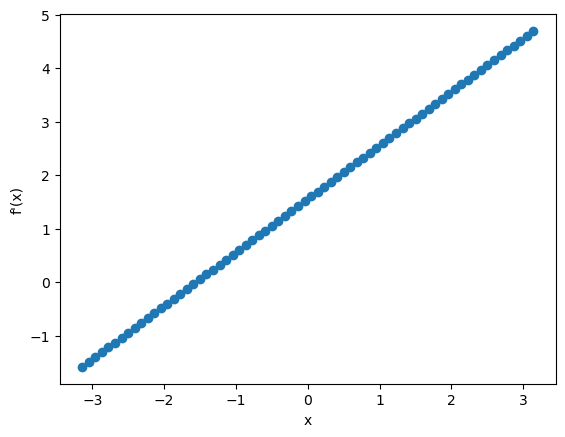

In [11]:
# part b
#Defining a user function for f(x)
def f(x):
    return (x+np.tan((np.cos(x)**2)+(np.sin(x)**2)))
#Plotting f(x) from x = -pi to pi
#Making a range for x
x_vals = np.linspace(-np.pi, np.pi, 70)
#Plotting and labeling
plt.scatter(x_vals, f(x_vals))
plt.xlabel("x")
plt.ylabel("f'(x)")

In order to plot, I defined the function f(x) as given. Then I created a range for the x values within the range given. Using those value, I then used plt.scatter to plot the xvals against the function. I added labels as well. 

In [23]:
# part c
print(fd([0,1]))


[np.float64(1.5574077246549023), np.float64(1.0)]


For this, I just printed the value of the function at t=0. This gives the derivative as 1, which makes sense bcause our graph has a slope of 1, and the derivative of the acutal function is 1. 